In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py
import os
print(os.getpid())
%cd ../../

import pylib.mix as mix
import cvxpy as cp
import pylib.qucf_read as qucf_r
import pylib.measurement as mse

import pylib.Chebyschev_coefs as ch

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

14227
/media/work/docs/codes/QuCF/scripts-py


In [15]:
path_save_ = "./jupyter-notebooks/Stepanoff/results/"
path_qucf_ = "../QuCF/simulations/Stepanoff/init"
for i in range(100):
    plt.close()

// --- For initialization subcircuit ---
	alpha_init_0 	0.000000000000e+00
	alpha_init_1 	1.576956312390e+00


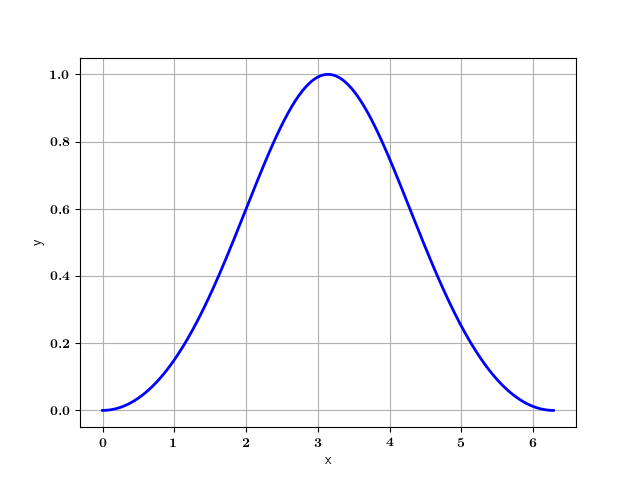

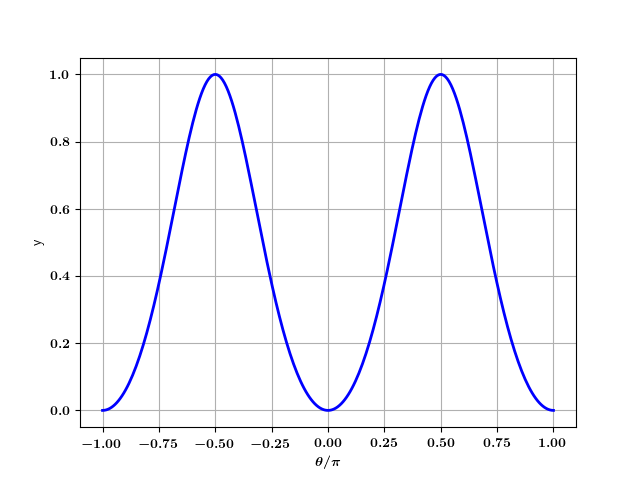

write data to a file: ./jupyter-notebooks/Stepanoff/results//init_sin_full.dat


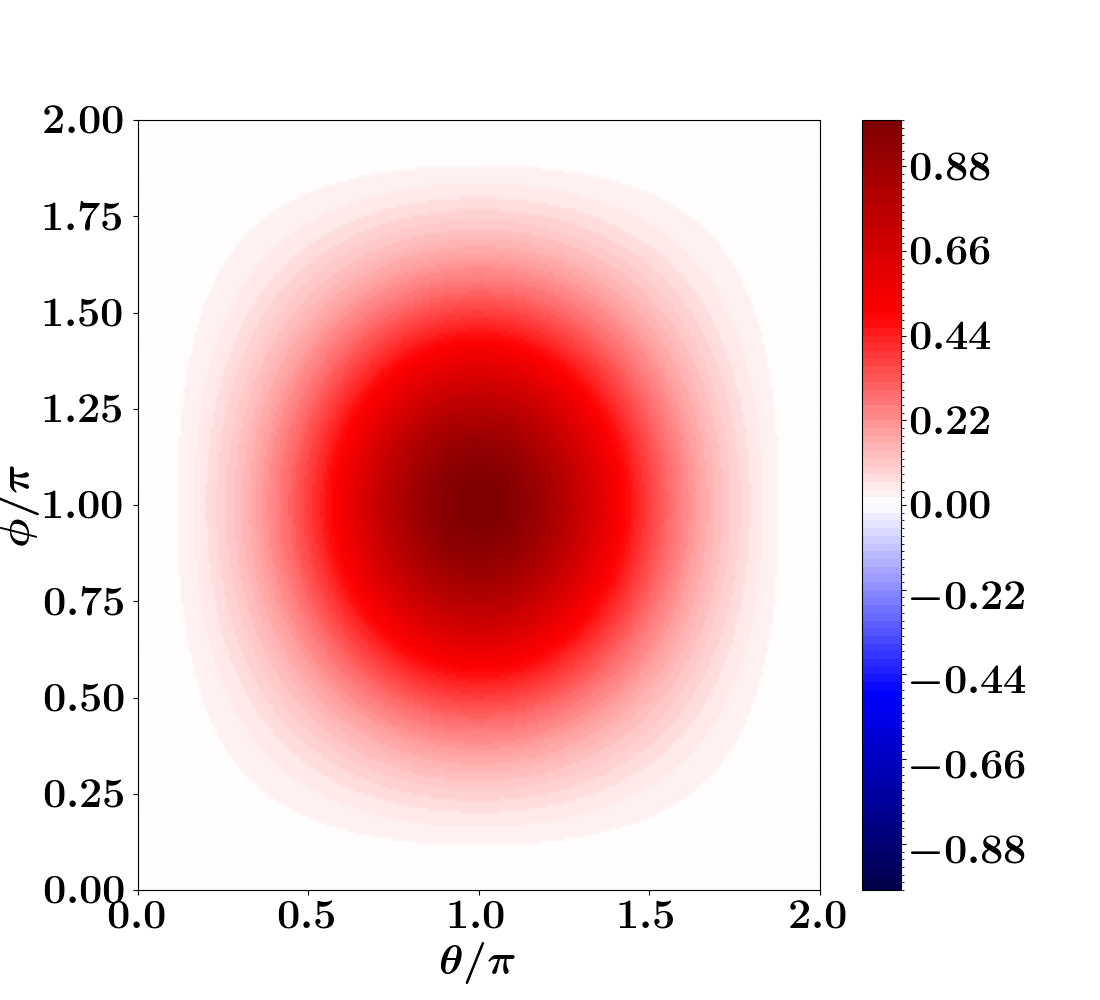

In [16]:
# -----------------------------------------------------
# --- Initial parameters ---
# -----------------------------------------------------
def plot_2D(X, Y, f, str_title="", fontsize = 30,):
    fig = plt.figure(figsize=(11,10))
    ax = fig.add_subplot(111)

    f_max_loc = np.max(np.abs(f))

    cmap = plt.get_cmap("seismic")
    levels = np.linspace(-f_max_loc, f_max_loc, 101) 
    divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    cs = ax.pcolormesh(X, Y, f, cmap=cmap, norm=divnorm, shading='gouraud') 
    cb = fig.colorbar(cs, ax = ax)
    cb.ax.ticklabel_format(style="scientific")
    cb.ax.tick_params(labelsize=fontsize) 

    ax.set_xlabel('$\\theta/\pi$', fontsize = fontsize)
    ax.set_ylabel("$\phi/\pi$", fontsize = fontsize)
    # ax.set_title(str_title)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    # ax.grid()
    return
# -----------------------------------------------------
def plot_init(x, f_init):
    Nx = len(x)

    f_cl = f_init(x)
    f_cl_2D = np.zeros((Nx, Nx))
    for ii in range(Nx):
        for kk in range(Nx):
            f_cl_2D[ii,kk] = f_cl[ii] * f_cl[kk]

    # --- Plotting 1D ---
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(x, f_cl, color="b", linewidth = 2, linestyle='-')
    plt.xlabel('x')
    plt.ylabel("y")
    plt.grid(True)
    plt.show()

    # --- Plotting 2D ---
    X, Y = np.meshgrid(x/np.pi, x/np.pi)
    plot_2D(X, Y, f_cl_2D, "initial conditions (norm. to max.)")
    return
# -----------------------------------------------------
def plot_and_save_sin_full(N):
    x = np.linspace(-np.pi, np.pi, N) 

    f_loc = lambda x1: np.exp(kappa_ * np.sin(x1)**2) - 1
    y = f_loc(x) / f_loc(np.pi/2.)

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(x/np.pi, y, color="b", linewidth = 2, linestyle='-')
    plt.xlabel('$\\theta/\pi$')
    plt.ylabel("y")
    plt.grid(True)
    plt.show()

    mix.save_dat_plot_1d_file(path_save_ + "/init_sin_full.dat", x/np.pi, y)
    return
# -----------------------------------------------------
def compute_sin_parameters(N):
    # --- for angle = [0, np.pi] ---
    alpha_0 = 0.
    alpha_1 = np.pi * N/(2.*(N - 1))

    print("// --- For initialization subcircuit ---")
    print("\talpha_init_0 \t{:0.12e}".format(alpha_0))
    print("\talpha_init_1 \t{:0.12e}".format(alpha_1))
    return
# -----------------------------------------------------
def f_init_(x):
    # y = np.exp(kappa_ * np.sin(x/2.)**2) - 1
    f_loc = lambda x1: np.exp(kappa_ * np.sin(x1/2.)**2) - 1
    y = f_loc(x) / f_loc(np.pi)
    return y
# -----------------------------------------------------
n_, kappa_, rr_init_ = 8, 1., 3.235340338884e+00
N_ = 1 << n_

x_ = np.linspace(0., 2.*np.pi, N_)

compute_sin_parameters(N_)
plot_init(x_, f_init_)

plot_and_save_sin_full(N_)

Reading the file ../QuCF/simulations/Stepanoff/init/init_OUTPUT.hdf5...
Probabilities have been saved in these QuCF simulations.
Name of the simulation is init
Simulation has been performed  02-13-2025 14:20:17

-----------------------------------------------------------
N-gates: 2484
max-abs-err: 2.116e-12
A-max (before renorm.): 1.238515950538e-02
success prob. (before renorm.): 9.999997016697e-01


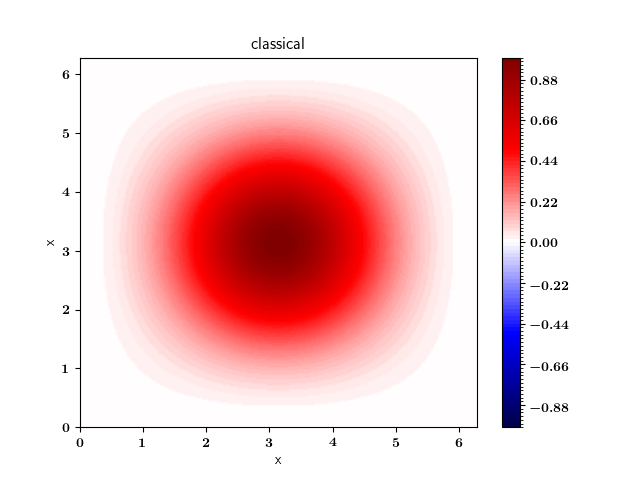

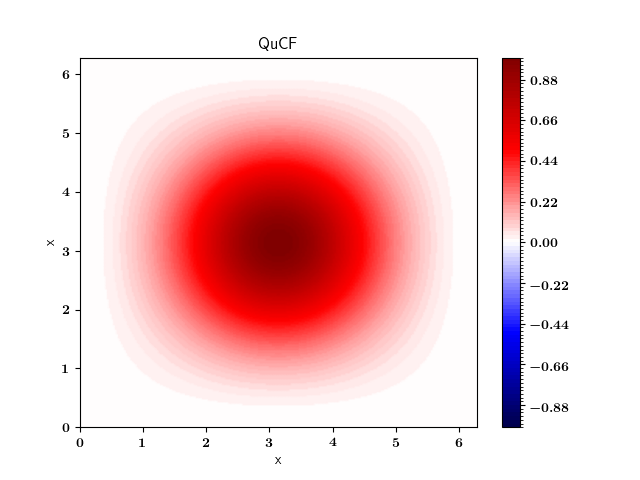

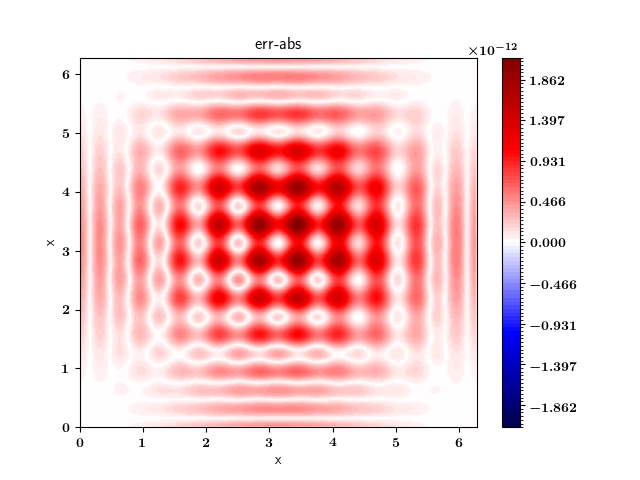

In [34]:
# -------------------------------------------------------------
# --- Compare QuCF (QSVT) and classical initializations ---
# -------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(mse)
def plot_qucf_initialization_1D(f_init):
    # --- reading QuCF simulations ---
    om = mse.MeasOracle__()
    om.path_  = path_qucf_
    om.pname_ = "init"
    om.open()

    # --- spatial grid ---
    nx = int(om.constants_["nx"])
    Nx = 1 << nx
    x = np.linspace(0, 2.*np.pi, Nx)

    # --- rescaling factors ---
    om.read_qsvt()
    resc_qsvt = om.dd_["init"]["rescaling_factor"]
    Hadamart_norm_factor = 2.**(nx/2)
    resc_coef = Hadamart_norm_factor / resc_qsvt

    # --- QuCF signal ---
    om.set_zero_ancillae_work_states(0)
    f_qucf = om.get_var_x({}, "r")
    f_qucf = f_qucf[:Nx]
    f_qucf = f_qucf.real

    # --- normalization of the QuCF signal ---
    # f_qucf *= resc_coef
    f_qucf /= np.max(np.abs(f_qucf))

    # --- classical data ---
    f_cl = f_init(x)
    f_cl /= np.max(np.abs(f_cl))

    # --- Errors ---
    err_abs = np.abs(f_cl - f_qucf)
    max_err = np.max(err_abs)
    print("max-abs-err: {:0.3e}".format(max_err))

    # --- Plotting ---
    fig1, axs = plt.subplots(1, 2)

    axs[0].plot(x, f_cl,   "-b", label = "CL") 
    axs[0].plot(x, f_qucf, ":r", label = "QuCF") 
    axs[0].set_xlabel('x')
    axs[0].set_ylabel("y/max(y)")
    axs[0].grid()
    axs[0].legend()

    axs[1].plot(x, err_abs,   "-b") 
    axs[1].set_xlabel('x')
    axs[1].set_ylabel("$|CL - QuCF|$")
    axs[1].grid()

    plt.tight_layout()
    return
# -------------------------------------------------------------
def plot_qucf_initialization_2D(f_init, flag_plot, flag_AA, flag_plot_1D = False):
    '''
    > When AA is included, keep flag_AA = False, 
      to find the amplitude of the amplified signal to compute rr.
    > Set flag_AA = True, when AA is included in QuCF simulations and 
      when rr has already been found.
    '''

    # --- reading QuCF simulations ---
    om = mse.MeasOracle__()
    om.path_  = path_qucf_
    om.pname_ = "init"
    om.open()

    # --- The total number of gates in the circuit ---
    Ngates = om.dd_["N-gates"]

    # --- spatial grid ---
    nx = int(om.constants_["nx"])
    Nx = 1 << nx
    x = np.linspace(0, 2.*np.pi, Nx)

    # --- rescaling factors ---
    om.read_qsvt()
    resc_qsvt = om.dd_["init"]["rescaling_factor"]

    Hadamart_norm_factor = 2.**(nx/2)
    resc_coef = (Hadamart_norm_factor / resc_qsvt)**2
    if flag_AA:
        resc_coef *= 1. / rr_init_

    # --- QuCF signal ---
    om.set_zero_ancillae_work_states(0)
    f_qucf = om.get_var_x({}, "r")

    succ_prob = np.sum(np.abs(f_qucf)**2)
    max_ampl = np.max(np.abs(f_qucf))

    f_qucf = f_qucf.real
    f_qucf_2D = f_qucf.reshape(Nx, Nx)

    # --- normalization of the QuCF signal ---
    # f_qucf_2D *= resc_coef
    f_qucf_2D /= np.max(np.max(np.abs(f_qucf_2D)))

    # --- Plotting 1D format of the 2D data ---
    if flag_plot_1D:
      fig, ax = plt.subplots()
      ax.plot(range(Nx*Nx), f_qucf, "-r", label = "QuCF") 
      ax.set_xlabel('x')
      ax.set_ylabel("y")
      ax.grid()
      ax.legend()

    # --- classical data ---
    f_cl = f_init(x)
    f_cl_2D = np.zeros((Nx, Nx))
    for ii in range(Nx):
        for kk in range(Nx):
            f_cl_2D[ii,kk] = f_cl[ii] * f_cl[kk]
            
    f_cl_2D /= np.max(np.abs(f_cl_2D))
    
    # --- Errors ---
    err_abs_2D = np.abs(f_cl_2D - f_qucf_2D)
    max_err = np.max(err_abs_2D)

    # --- Printing data ---
    print("\n-----------------------------------------------------------")
    print("N-gates: {:d}".format(Ngates))
    print("max-abs-err: {:0.3e}".format(max_err))
    if not flag_AA:
      print("A-max (before renorm.): {:0.12e}".format(max_ampl))
      print("success prob. (before renorm.): {:0.12e}".format(succ_prob))

    # --- Plotting ---
    if flag_plot:
        X, Y = np.meshgrid(x, x)
        plot_2D(X, Y, f_cl_2D, "classical")
        plot_2D(X, Y, f_qucf_2D, "QuCF")
        plot_2D(X, Y, err_abs_2D, "err-abs")
    return 
# -----------------------------------------------------
flag_plot, flag_AA = True, False

# plot_qucf_initialization_1D(f_init_)
plot_qucf_initialization_2D(f_init_, flag_plot, flag_AA)
del flag_plot, flag_AA

In [28]:
# ----------------------------------------------------------
# --- Amplitude amplification ---
# ----------------------------------------------------------
def print_rr(line_str, A_ampl, A_non_ampl):
    rr = A_ampl / A_non_ampl
    print("{:s}:\t rr = {:0.12e}".format(line_str, rr))
    return
# ---------------------------------------
# *** Here, succ_prob is a non-amplified success probability. ***
def print_NA(line_str, succ_prob):
    theta_AA = np.arcsin(np.sqrt(succ_prob))
    N_AA = int(0.5 * (np.pi/(2.*theta_AA) - 1.))  # +/- 1
    print("{:s}:\t N_AA {:d}".format(line_str, N_AA))
    return
# ---------------------------------------
def compute_AA_init():
    # --- Compute the ration between amplified and non-amplified signals ---
    print_rr("kappa = 1.0,  n =  8", 1.238516052657e-02, 3.828085836201e-03)

    # --- Compute the number of repetitions of the AA operator: +/- 1 ---
    print()
    print_NA("kappa = 1.0,  nk =  7", 9.553444759810e-02)
    return
# ---------------------------------------
compute_AA_init()

kappa = 1.0,  n =  8:	 rr = 3.235340338884e+00

kappa = 1.0,  nk =  7:	 N_AA 1


Reading the file ../QuCF/simulations/Stepanoff/init/init_OUTPUT.hdf5...
Probabilities have been saved in these QuCF simulations.
Name of the simulation is init
Simulation has been performed  02-14-2025 11:07:22
max-abs-err: 8.848e-14


/tmp/ipykernel_8583/2695368138.py:52: RuntimeWarning: divide by zero encountered in log
  axs[0].plot(k_array, np.log(fft_qucf), color='r',  marker='o', linewidth = 2, linestyle=':', label = "QuCF")


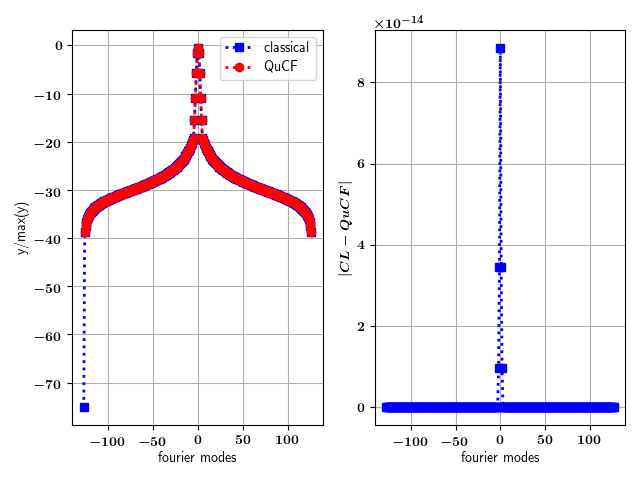

In [ ]:
# ----------------------------------------------------------------------------------
# --- Compare QuCF (QSVT) and classical FOURIER TRANSFORM of the initializations ---
# ----------------------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(mse)
def plot_qucf_init_FOURIER_1D(f_init):
    # --- reading QuCF simulations ---
    om = mse.MeasOracle__()
    om.path_  = path_qucf_
    om.pname_ = "init"
    om.open()

    # --- spatial grid ---
    nx = int(om.constants_["nx"])
    Nx = 1 << nx
    x = np.linspace(0, 2.*np.pi, Nx)

    # --- Fourier grid ---
    coef_ff = 2.*np.pi
    dx = np.diff(x)[0]
    dk = coef_ff / (dx*Nx)
    k_array_pos = np.linspace(              0, coef_ff/(2*dx) - dk, Nx//2) 
    k_array_neg = np.linspace(-coef_ff/(2*dx),                 -dk, Nx//2)
    k_array = np.concatenate((k_array_neg, k_array_pos))
    # k_array = np.fft.fftfreq(Nx, d=1/(dx*Nx))  # Frequency bins

    # --- QuCF signal ---
    om.set_zero_ancillae_work_states(0)
    fft_qucf = om.get_var_x({}, "r")
    fft_qucf = fft_qucf[:Nx]
    fft_qucf = np.concatenate( (fft_qucf[Nx//2:Nx], fft_qucf[0:Nx//2]) )
    fft_qucf = np.abs(fft_qucf)**2 / np.sum(np.abs(fft_qucf)**2)

    # --- classical Fourier ---
    f_cl = f_init(x)
 
    # f_cl = np.sin(x * 40.)  # >>> for testing

    fft_cl = np.fft.fft(f_cl)
    fft_cl = np.concatenate( (fft_cl[Nx//2:Nx], fft_cl[0:Nx//2]) ) 
    fft_cl = np.abs(fft_cl)**2 / np.sum(np.abs(fft_cl)**2)

    # --- Errors ---
    err_abs = np.abs(fft_cl - fft_qucf)
    max_err = np.max(err_abs)
    print("max-abs-err: {:0.3e}".format(max_err))

    # --- Plotting ---
    fig1, axs = plt.subplots(1, 2)

    axs[0].plot(k_array, np.log(fft_cl),   color='b',  marker='s', linewidth = 2, linestyle=':', label = "classical") 
    axs[0].plot(k_array, np.log(fft_qucf), color='r',  marker='o', linewidth = 2, linestyle=':', label = "QuCF") 
    axs[0].set_xlabel('fourier modes')
    axs[0].set_ylabel("log(y/max(y))")
    axs[0].grid()
    axs[0].legend()

    axs[1].plot(k_array, err_abs, color='b',  marker='s', linewidth = 2, linestyle=':')
    axs[1].set_xlabel('fourier modes')
    axs[1].set_ylabel("$|CL - QuCF|$")
    axs[1].grid()

    plt.tight_layout()
    return
# -------------------------------------------------------------
flag_plot, flag_AA = True, False

plot_qucf_init_FOURIER_1D(f_init_)
# plot_qucf_init_FOURIER_2D(f_init_, flag_plot, flag_AA)
del flag_plot, flag_AA

Function parameter:		 1.000e+00
Chosen function, parity:	 exp_x_squ, 0

max. |norm y|: 9.900e-01


Minimization method is used.
Computation status:  1.2626460879780833e-22

Chosen polynomial's degree:	 20
Number of coefficients:		 10
max. abs. error: 5.136e-13


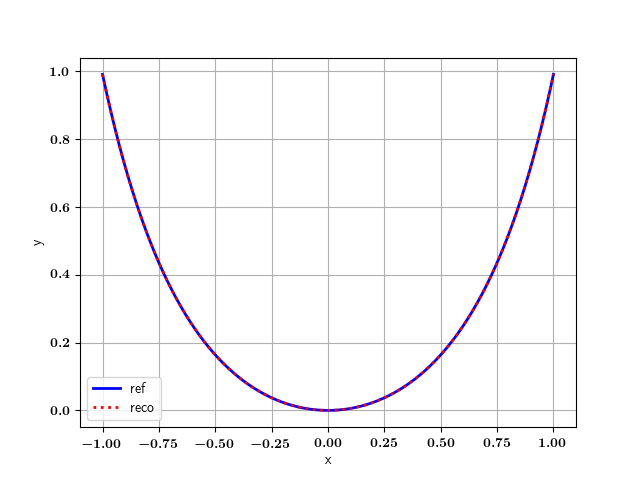

In [10]:
# ------------------------------------------------------------
# --- Computing Chebyschev for initial conditions ---
# ------------------------------------------------------------
mix.reload_module(ch)
def compute_Chebyschev_coefficients(par1, Nd, Nx):
    sel_method = 0
    id_fun = 13

    oo_ch = ch.Ch_()
    oo_ch.choose_method(sel_method)
    oo_ch.choose_func(id_fun, par1)
    oo_ch.compute_Ch(Nd, Nx = Nx)
    oo_ch.plot_reconstructed_function()
    return oo_ch
# -----------------------------------------------------------
def compute_QSVT_angles(oo_ch):
    with h5py.File(oo_ch.full_fname_, "r") as f:
        gr = f["basic"]
        eps_res = np.abs(gr["eps"][()])
    eps_res_log = int(np.round(np.log10(eps_res)))

    filename_angles = "angles_{:s}_par{:s}_eps{:d}".format(oo_ch.line_f_, oo_ch.line_par_, abs(eps_res_log))

    oo_aa = ch.ComputeQSVT_angles_(
        loc_dir_angles = "Stepanoff_Init/",
        filename_coef_without_format = oo_ch.fname_without_format_,
        filename_angles_without_format = filename_angles
    )
    oo_aa.compute_QSVT_angles()
    return
# -----------------------------------------------------------

# --- Compute the coefficients ---
oo_ch_ = compute_Chebyschev_coefficients(
    par1 = kappa_, 
    Nd = 20,
    Nx = 1001
)

# # --- Save the coefficients ---
# oo_ch_.save_coefficients()

# # --- Compute QSVT angles ---
# compute_QSVT_angles(oo_ch_)

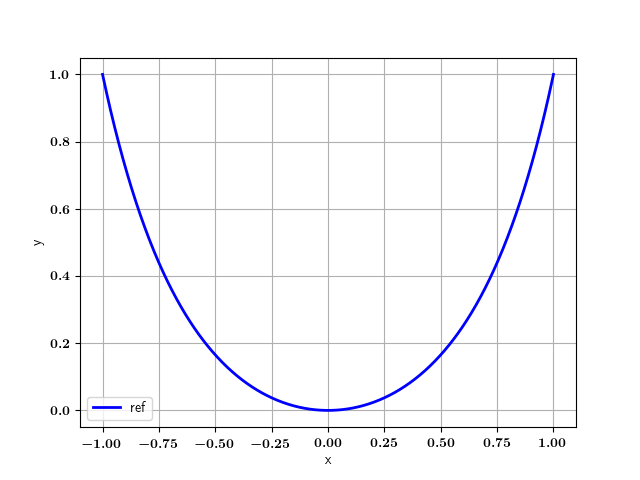

In [23]:
# --------------------------------------------------------------------------------
def test_functions():
    kappa = 1.0

    Nx = 1001
    x = np.linspace(-1., 1., Nx)

    # y = np.exp(kappa * x)
    # y = np.exp(kappa * np.cos(np.pi*x))

    # y = np.sin(np.pi*x)**2
    # y = x**2

    # y = np.exp(kappa * np.sin(np.pi*x)**2) - 1
    # y = np.exp(kappa * x**2) - 1
    # y /= np.max(np.abs(y))

    f_loc = lambda x1: np.exp(kappa * x1**2) - 1.
    y = f_loc(x) / f_loc(1.)

    fig = plt.figure()
    ax = fig.add_subplot(111)

    ax.plot(x, y, color="b", linewidth = 2, linestyle='-', label = "ref")

    plt.xlabel('x')
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()
    return
# --------------------------------------------------------------------------------
def test_Fourier():
    # Sample rate and signal duration
    fs = 1000  # Sampling frequency in Hz
    T = 1.0    # Duration in seconds
    t = np.linspace(0, T, fs, endpoint=False)  # Time vector

    # Create a signal with multiple frequency components
    f1, f2 = 50, 150  # Frequencies in Hz
    signal = np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)

    # Compute FFT
    N = len(signal)
    fft_values = np.fft.fft(signal)
    frequencies = np.fft.fftfreq(N, d=1/fs)  # Frequency bins

    # Only take the positive half of frequencies (since FFT is symmetric)
    half_N = N // 2


    print(fs)
    print(N)
            
    # --- Plotting ---
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(frequencies[:half_N], np.abs(fft_values[:half_N]) / N)  # Normalize amplitude
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.title('FFT of the Signal')
    plt.grid()
    plt.show()
    return
# ----------------------------------------------------------
test_functions()
# test_Fourier()